In [8]:
import numpy as np
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath("../libs"))
sys.path.append(os.path.abspath("../utils"))


from normalizers.min_max_scaler import MinMaxScaler
from networks.wavelet import (
    unflatten_weights,
    hidden_forward,
    train_network_wavelet
)
from activations.activations import mexican_hat_wavelet
from metrics.metrics import R2_score, MSE, MAE, RMSE

pd.set_option("display.float_format", "{:.5f}".format)

# Ajuste de curva por otimização

## Gerar os dados

In [9]:
# Carregamento dos dados
def function_case_1(x: np.ndarray) -> np.ndarray:
    """
    Gera dados da função senoidal (caso 1) com ruído Gaussiano aditivo.

    Parâmetros:
    - x: O array de entrada.
    - noise_std: O desvio padrão (amplitude) do ruído.
                 Se 0.0, a função retorna o sinal limpo.
    Retorna:
    - O array de saída com o sinal ruidoso.
    """
    # Gerar o sinal limpo
    signal = 0.5 + 0.4 * np.sin(2 * np.pi * x)

    # Gerar o ruído Gaussiano
    variance = 0.05**2 + 0.1 * (1 - x**2)
    std_dec = np.sqrt(variance)

    noise = np.random.normal(loc=0.0, scale=std_dec, size=x.shape)

    # Retornar o sinal com ruído' aditivo
    return signal + noise

X_size_case_1 = 1000
X_case_1 = np.linspace(0, 1, X_size_case_1)
y_case_1 = function_case_1(X_case_1)

df = pd.DataFrame({
    "X": X_case_1,
    "y": y_case_1
})

df.head()

,X,y
0,0.00000,1.33290
1,0.00100,0.38678
2,0.00200,-0.17991
3,0.00300,1.10628
4,0.00400,0.80920


### Mostrar os dados gerados

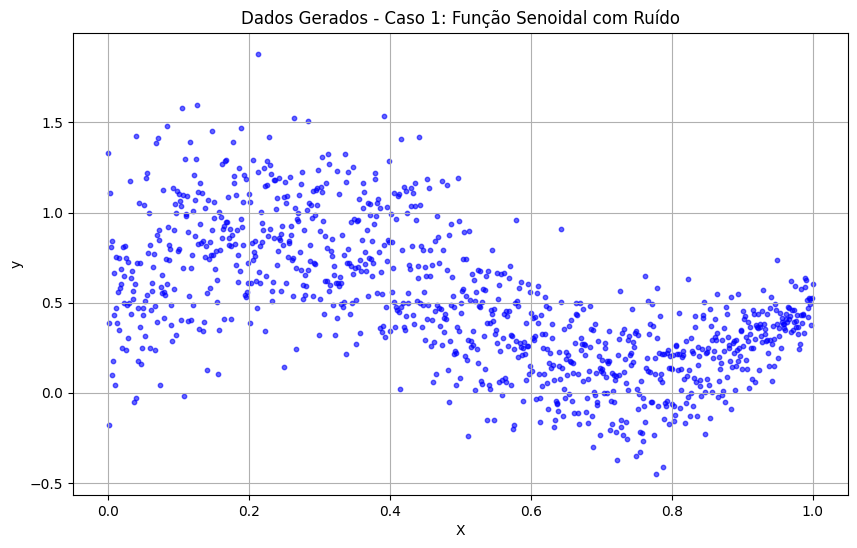

In [10]:
fig = plt.figure(figsize=(10, 6))
plt.scatter(df["X"], df["y"], s=10, color='blue', alpha=0.6)
plt.title("Dados Gerados - Caso 1: Função Senoidal com Ruído")
plt.xlabel("X")
plt.ylabel("y")
plt.grid()

## Pré-processamento dos dados

In [11]:
X = df[["X"]]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Cria os normalizadores
scaler = MinMaxScaler(-1, 1)
scaler_y = MinMaxScaler(-1, 1)

# Ajusta os normalizadores aos dados
scaler.fit(X_train)
scaler_y.fit(y_train.to_frame())

# Normaliza os dados
X_train_scaled = scaler.normalize(X_train)
X_test_scaled = scaler.normalize(X_test)

y_train_scaled = scaler_y.normalize(y_train.to_frame()).squeeze()
y_test_scaled = scaler_y.normalize(y_test.to_frame()).squeeze()

### Rodar os experimentos

In [12]:
n_iterations = 1000
tolerance = 1e-9
alpha = 1e-3
num_neurons = 2
initializers = ["heuristic", "rbs", "sso"]
y_hats = {}

X_train_scaled_values = X_train_scaled["X"].values.reshape(-1, 1)
X_test_scaled_values = X_test_scaled["X"].values.reshape(-1, 1)

results = {}

for init_method in initializers:
    # Treinar a rede neural wavelet
    neurons_weights_flat, _, total_iter = train_network_wavelet(
        X_train_scaled_values,
        y=y_train_scaled.values,
        n_neurons=num_neurons,
        n_iterations=n_iterations,
        tolerance=tolerance,
        alpha=alpha,
        weights_init_method=init_method,
    )

    # Desempacotar os pesos finais
    num_inputs = 1
    neurons_params, output_weights = unflatten_weights(
        neurons_weights_flat, n_inputs=num_inputs, n_neurons=num_neurons
    )

    # Fazer previsão usando a rede treinada
    y_hat_scaled = hidden_forward(
        X_test_scaled_values,
        neurons_params=neurons_params,
        wavelet_fn=mexican_hat_wavelet,
        output_weights=output_weights
    )

    # Desnormalizar
    y_hat = scaler_y.denormalize(y_hat_scaled.reshape(-1, 1)).flatten()

    # Calcular métricas
    r2 = R2_score(y_test.values, y_hat)
    mse = MSE(y_test.values, y_hat)
    mae = MAE(y_test.values, y_hat)
    rmse = RMSE(y_test.values, y_hat)

    results[init_method] = {
        "R2": r2,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "Epochs": int(total_iter),
    }

    y_hats[init_method] = y_hat


Usando inicialização heurística.
Usando inicialização RBS.
Usando inicialização SSO.


## Resultados

In [13]:
# Exibir os resultados
results_df = pd.DataFrame(results).T
print("\nResultados das Métricas por Método de Inicialização:")
results_df


Resultados das Métricas por Método de Inicialização:


,R2,MSE,MAE,RMSE,Epochs
heuristic,0.51692,0.07147,0.20976,0.26734,172.00000
rbs,0.51506,0.07175,0.21018,0.26785,12.00000
sso,0.51506,0.07174,0.21018,0.26785,8.00000


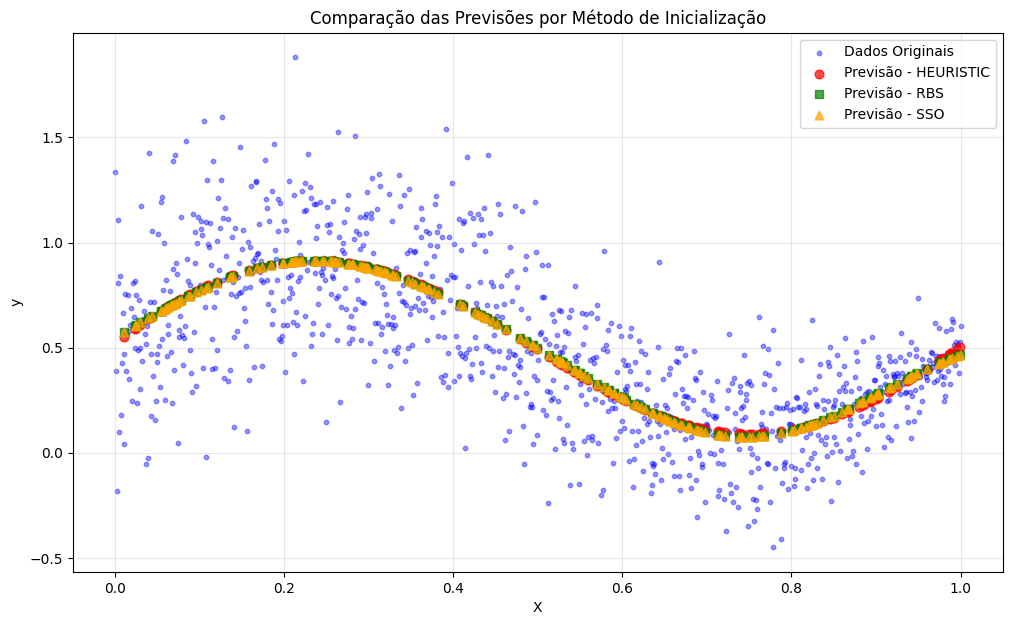

In [14]:
fig = plt.figure(figsize=(12, 7))

# Dados originais
plt.scatter(df["X"], df["y"], s=10, color='blue', alpha=0.4, label="Dados Originais")

#  Definir cores e marcadores para todos os métodos
colors = {
    'heuristic': 'red',
    'rbs': 'green',
    'sso': 'orange',
}
markers = {
    'heuristic': 'o',
    'rbs': 's',
    'sso': '^',
}

# Plotar previsões de cada método
for init_method in initializers:
    if init_method in y_hats:  #  Verificar se existe
        plt.scatter(
            X_test["X"].values,
            y_hats[init_method],
            s=40,
            color=colors.get(init_method, 'purple'),
            alpha=0.7,
            marker=markers.get(init_method, 'x'),
            label=f"Previsão - {init_method.upper()}"
        )

plt.title("Comparação das Previsões por Método de Inicialização")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.legend()
plt.show()